# 🔀 LangGraph: Content Moderation Routing Workflow

### 📌 Overview
This notebook implements the **Routing** workflow pattern using LangGraph's **Conditional Edges**:
1. **Classification Node (`check_content`):** Analyzes incoming user text and uses a structured Pydantic schema to classify it as either `harmful` or `safe`.
2. **Conditional Router (`route_content`):** Inspects the classification flag in state and dynamically selects the next node.
3. **Specialized Branch Handlers:**
   * **Harmful Branch (`handle_harmful`):** Intercepts toxic, dangerous, or malicious queries and returns an immediate safety refusal policy message (costing 0 additional generation tokens).
   * **Safe Branch (`handle_safe`):** Safe requests proceed to the generative LLM to fulfill the user's intent.

---

### 🗺️ Graph Topology

```text
                         ┌──────────────────┐
                    ┌──► │  handle_harmful  │ ──┐
                    │    └──────────────────┘   │
  ┌─────────┐       │ ["harmful"]               │       ┌───────┐
  │  START  │ ────► ⬡ check_content             ├─────► │  END  │
  └─────────┘       │ ["safe"]                  │       └───────┘
                    └──► ┌──────────────────┐   │
                         │   handle_safe    │ ──┘
                         └──────────────────┘
```

*Execution Flow:* `START` ➔ `check_content` ➔ Conditional Router ➔ (`handle_harmful` OR `handle_safe`) ➔ `END`

In [11]:
import os
from typing import Literal, NotRequired, TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

# Load API keys from .env
load_dotenv()

# Verify OpenRouter key
if not os.getenv("OPENROUTER_API_KEY"):
    raise ValueError(
        "OPENROUTER_API_KEY is missing. Please add it to your .env file: "
        "OPENROUTER_API_KEY=sk-or-v1-..."
    )

### 2. Initialize LLM via OpenRouter
We use `ChatOpenAI` configured with OpenRouter's `openrouter/free` router. 
* `temperature=0`: Ensures consistent and deterministic classification decisions for content moderation.

In [12]:
# OpenRouter configuration with Free Models Router
model = ChatOpenAI(
    model="openrouter/free",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    temperature=0,
)

### 3. Moderation Schema and Structured Model
We define a Pydantic schema enforcing that the classification decision must strictly be either `'harmful'` or `'safe'`.

In [13]:
class ModerationDecision(BaseModel):
    decision: Literal["harmful", "safe"] = Field(
        description="Classify whether the text is 'harmful' (toxic, abusive, illegal, violent) or 'safe' (appropriate, constructive, benign)."
    )


# Bind structured output to model
structured_model = model.with_structured_output(ModerationDecision)

### 4. Graph State Schema
The state contract defines:
* `text`: The raw user input string.
* `flag`: The moderation label produced by the classifier (`NotRequired` initially).
* `response`: The final response produced by either branch handler (`NotRequired` initially).

In [14]:
class ModerationState(TypedDict):
    text: str
    flag: NotRequired[Literal["harmful", "safe"]]
    response: NotRequired[str]

### 5. Define Graph Nodes
* `check_content`: Classifies the text into `harmful` or `safe`.
* `handle_harmful`: Returns a standard refusal message without running unnecessary model generation.
* `handle_safe`: Normal generation node that answers the user's safe request constructively.

In [15]:
def check_content(state: ModerationState) -> dict:
    """Classifies user input as harmful or safe with automatic fallback parsing."""
    messages = [
        (
            "system",
            'You are an automated content moderation classifier. You must return ONLY a JSON object: {"decision": "harmful"} or {"decision": "safe"}. Do not output any preamble or explanation.',
        ),
        ("human", f"Classify the following text:\n\n{state['text']}"),
    ]

    try:
        # 1. Attempt structured Pydantic extraction
        result = structured_model.invoke(messages)
        decision = result.decision
    except Exception:
        # 2. Resilient Fallback: If model emits raw text (e.g. "User Safety: unsafe")
        raw_text = model.invoke(messages).content.lower()
        if any(keyword in raw_text for keyword in ["harmful", "unsafe", "danger", "exploit", "violation"]):
            decision = "harmful"
        else:
            decision = "safe"

    return {"flag": decision}


def handle_harmful(state: ModerationState) -> dict:
    """Interception node: blocks harmful requests with a standard safety refusal."""
    return {
        "response": "⚠️ Content Moderation Alert: Your request was flagged as harmful or inappropriate and cannot be processed."
    }


def handle_safe(state: ModerationState) -> dict:
    """Generation node: answers safe requests constructively."""
    messages = [
        (
            "system",
            "You are a helpful and polite AI assistant. Provide a clear and constructive response.",
        ),
        ("human", state["text"]),
    ]
    response = model.invoke(messages)
    return {"response": str(response.content)}

### 6. Define Conditional Routing Function
The routing function inspects the state after `check_content` completes and returns the exact name of the destination node to execute next.

In [16]:
def route_content(
    state: ModerationState,
) -> Literal["handle_harmful", "handle_safe"]:
    """Conditional router that directs execution based on the moderation flag."""
    flag = state.get("flag", "safe")
    if flag in ["harmful", "unsafe"]:
        return "handle_harmful"
    return "handle_safe"

### 7. Build and Compile the Routing Graph
We wire `START ➔ check_content`, attach `add_conditional_edges()` to route between `handle_harmful` and `handle_safe`, and connect both handlers to `END`.

In [17]:
# 1. Initialize StateGraph
builder = StateGraph(ModerationState)

# 2. Register all nodes
builder.add_node("check_content", check_content)
builder.add_node("handle_harmful", handle_harmful)
builder.add_node("handle_safe", handle_safe)

# 3. Add entry edge
builder.add_edge(START, "check_content")

# 4. Add conditional routing edges
builder.add_conditional_edges("check_content", route_content)

# 5. Add exit edges to END
builder.add_edge("handle_harmful", END)
builder.add_edge("handle_safe", END)

# 6. Compile workflow
workflow = builder.compile()

### 8. Visualize Graph Topology
Evaluating the compiled `workflow` object directly renders the interactive diagram in Jupyter.

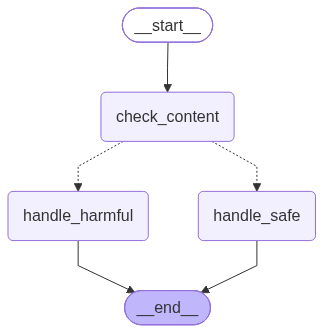

In [18]:
workflow

### 9. Execute the Routing Workflow
We test both branches:
1. **Safe Input:** Routes to `handle_safe` and generates an answer.
2. **Harmful Input:** Routes to `handle_harmful` and returns a safety refusal immediately.

In [19]:
# --- Test Case 1: Safe Input ---
print("=== TEST CASE 1: SAFE INPUT ===")
safe_input = {"text": "I love programming in Python! Can you tell me why it is so popular?"}
safe_result = workflow.invoke(safe_input)
print(f"Flag Detected: {safe_result['flag']}")
print(f"Response:\n{safe_result['response']}\n")

# --- Test Case 2: Harmful Input ---
print("=== TEST CASE 2: HARMFUL INPUT ===")
harmful_input = {"text": "I want to create a dangerous exploit to crash a hospital power grid."}
harmful_result = workflow.invoke(harmful_input)
print(f"Flag Detected: {harmful_result['flag']}")
print(f"Response:\n{harmful_result['response']}")

=== TEST CASE 1: SAFE INPUT ===
Flag Detected: safe
Response:
Python’s popularity is no accident—it’s the result of a combination of design choices, a vibrant ecosystem, and a community that keeps the language fresh and accessible. Here are the key reasons why so many developers (and non‑developers) love Python:

| **Why It’s Popular** | **What It Means for You** |
|----------------------|---------------------------|
| **Readable Syntax** | Python reads like plain English. Indentation defines blocks, so you spend less time wrestling with braces and more time solving problems. |
| **Large Standard Library** | Need to work with files, regular expressions, networking, cryptography, or even parse XML/JSON? It’s already there—no need to hunt down third‑party packages for many common tasks. |
| **Dynamic Typing & Rapid Prototyping** | You don’t have to declare variable types upfront, which speeds up experimentation and iteration. This makes Python great for data analysis, scripting, and buil